In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import warnings 
warnings.filterwarnings("ignore")

In [31]:
iris=load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [32]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head(4)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2


In [33]:
df["Target"]=iris.target
df.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [35]:
# null check and processing
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

In [36]:
# duplicate check
df.duplicated().sum()
# keeping this because currently we have balanced target

np.int64(1)

In [37]:
df["Target"].value_counts()

Target
0    50
1    50
2    50
Name: count, dtype: int64

In [38]:
# statistical distribution check - Skewness and outlier check
df[['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)']].describe()
# -vely skewed - petal length (cm)	
# +vely skewed - none
# normally distributed- rest all

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


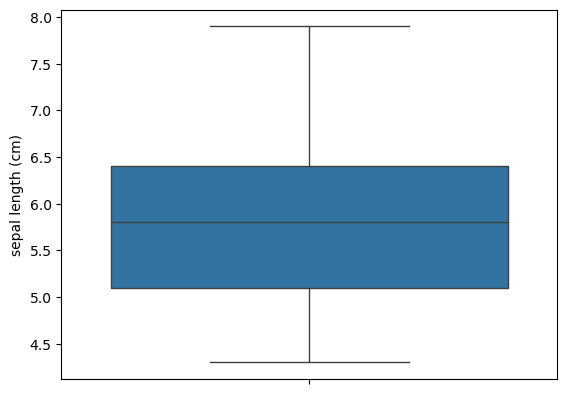

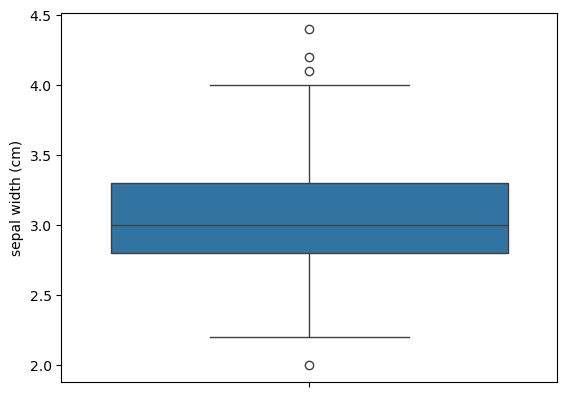

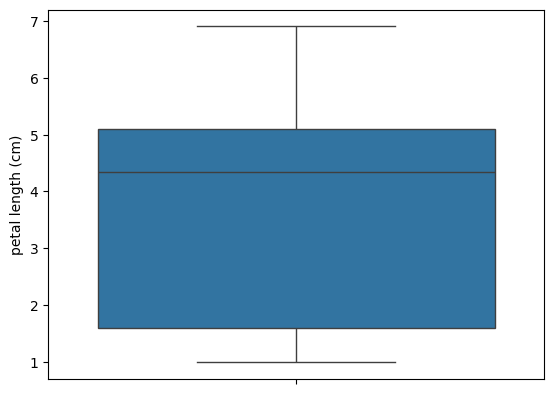

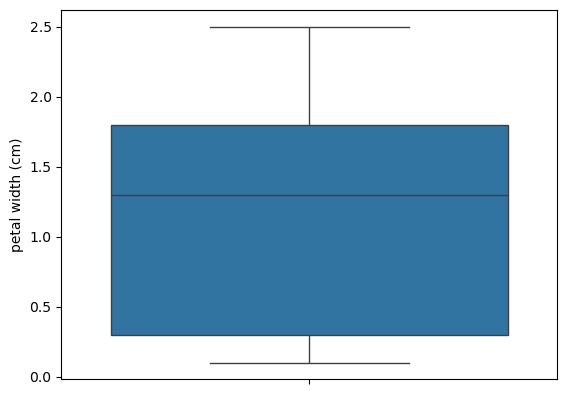

In [39]:
# boxplots
num_col=['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)']
for i in num_col:
    sns.boxplot(df[i])
    plt.show()
# Sepal width has outliers but we r keeping outliers

In [40]:
# skewness check
from scipy.stats import skew
for i in num_col:
    print(f"{i} : {skew(df[i])}")
# not very highly skewed

sepal length (cm) : 0.3117530585022963
sepal width (cm) : 0.31576710633893473
petal length (cm) : -0.2721276664567214
petal width (cm) : -0.10193420656560036


In [41]:
# object encoding- no object type datatype
# target is categorical

In [42]:
features=df.drop("Target",axis=1)
target=df["Target"]

In [43]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
features.iloc[:]=ss.fit_transform(features.iloc[:])
features.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444


In [44]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,random_state=0,test_size=0.2)
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(120, 4) (120,)
(30, 4) (30,)


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [46]:
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    #Overfitting - underfitting check
    print(f"Training score : {model.score(xtrain,ytrain)}")
    print(f"Testing score : {model.score(xtest,ytest)}")
    c=pd.DataFrame(confusion_matrix(ypred,ytest),
                  index=["Setosa","Virginica","Versicolor"],
                  columns=["Setosa","Virginica","Versicolor"])
    print("Confusion Matrix : \n",c)
    print("Classification Report : \n",classification_report(ytest,ypred))
    return model

In [47]:
dt=mymodel(DecisionTreeClassifier())

Training score : 1.0
Testing score : 1.0
Confusion Matrix : 
             Setosa  Virginica  Versicolor
Setosa          11          0           0
Virginica        0         13           0
Versicolor       0          0           6
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [48]:
d={
    "Columns":xtrain.columns,
    "Feature Importance ": dt.feature_importances_
}
g=pd.DataFrame(d)
g

,Columns,Feature Importance
0,sepal length (cm),0.000000
1,sepal width (cm),0.012534
2,petal length (cm),0.064446
3,petal width (cm),0.923020


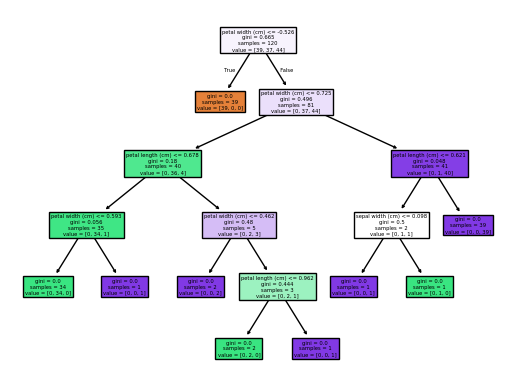

In [49]:
from sklearn import tree
tree.plot_tree(dt,feature_names=xtrain.columns,filled=True)
plt.show()

In [50]:
dt.get_depth()

5

In [51]:
dt.get_n_leaves()

np.int64(9)

In [52]:
# to deal with overfitting apply hyperparameter tuning
# applying pruning techniques
parameters={
    "max_depth":list(range(2,5)), # 2,3,4
    "min_samples_split":list(range(2,5)), # 2,3,4
    "min_samples_leaf":list(range(3,9))  #3,4,5,6,7,8
}
# 3*3*6 = 54

In [53]:
from sklearn.model_selection import GridSearchCV
clf=GridSearchCV(DecisionTreeClassifier(),parameters,verbose=2)
clf.fit(xtrain,ytrain)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=3, min_samples_split=4; total time=   0.0s
[CV] END max_depth=2, min_samples_le

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 3, 4],
                         'min_samples_leaf': [3, 4, 5, 6, 7, 8],
                         'min_samples_split': [2, 3, 4]},
             verbose=2)

In [54]:
clf.best_estimator_

DecisionTreeClassifier(max_depth=2, min_samples_leaf=3, min_samples_split=3)

In [55]:
c=mymodel(clf.best_estimator_) # DecisionTreeClassifier(max_depth=2, min_samples_leaf=4)

Training score : 0.9583333333333334
Testing score : 0.9666666666666667
Confusion Matrix : 
             Setosa  Virginica  Versicolor
Setosa          11          0           0
Virginica        0         13           1
Versicolor       0          0           5
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.93      1.00      0.96        13
           2       1.00      0.83      0.91         6

    accuracy                           0.97        30
   macro avg       0.98      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30



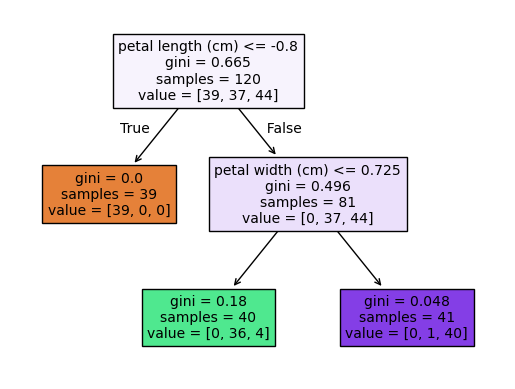

In [56]:
tree.plot_tree(c,feature_names=xtrain.columns,filled=True)
plt.show()

In [57]:
g["After Pruning"]=c.feature_importances_ 

In [58]:
g # decision tree does feature selection



,Columns,Feature Importance,After Pruning
0,sepal length (cm),0.000000,0.00000
1,sepal width (cm),0.012534,0.00000
2,petal length (cm),0.064446,0.56045
3,petal width (cm),0.923020,0.43955


In [ ]:
#SVR
#SVC --------------

In [59]:
from sklearn.svm import SVC

In [60]:
svc=mymodel(SVC())

Training score : 0.9583333333333334
Testing score : 1.0
Confusion Matrix : 
             Setosa  Virginica  Versicolor
Setosa          11          0           0
Virginica        0         13           0
Versicolor       0          0           6
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [61]:
# hyper parameter tuning in SVC---
parameters ={"C":[0.01,0.1,1],
            "gamma":[0.01,0.1,1],
            "kernel":["rbf","poly"]}

In [62]:
from sklearn.model_selection import GridSearchCV
clf=GridSearchCV(SVC(),parameters,verbose=2)
clf.fit(xtrain,ytrain)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END ....................C=0.01, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.01, gamma=0.1

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1], 'gamma': [0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             verbose=2)

In [63]:
clf.best_params_

{'C': 0.1, 'gamma': 1, 'kernel': 'poly'}

In [64]:
clf.best_estimator_

SVC(C=0.1, gamma=1, kernel='poly')

In [65]:
svc_g=mymodel(clf.best_estimator_)

Training score : 0.9666666666666667
Testing score : 1.0
Confusion Matrix : 
             Setosa  Virginica  Versicolor
Setosa          11          0           0
Virginica        0         13           0
Versicolor       0          0           6
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [67]:
svc_g.n_support_

array([ 2, 14, 13], dtype=int32)

In [68]:
svc_g.support_vectors_

array([[-1.62768839, -1.74335684, -1.39706395, -1.18381211],
       [-0.90068117,  0.55861082, -1.16971425, -0.92054774],
       [-0.7795133 , -0.82256978,  0.08070915,  0.26414192],
       [ 0.18982966, -0.82256978,  0.76275827,  0.52740629],
       [ 0.55333328,  0.55861082,  0.53540856,  0.52740629],
       [ 0.18982966,  0.78880759,  0.42173371,  0.52740629],
       [-0.41600969, -1.28296331,  0.13754657,  0.13250973],
       [ 1.2803405 ,  0.09821729,  0.64908342,  0.3957741 ],
       [-0.90068117, -1.28296331, -0.4308277 , -0.13075464],
       [ 0.4321654 , -1.97355361,  0.42173371,  0.3957741 ],
       [-0.41600969, -1.74335684,  0.13754657,  0.13250973],
       [-1.14301691, -1.51316008, -0.26031542, -0.26238682],
       [ 0.55333328, -1.28296331,  0.64908342,  0.3957741 ],
       [ 1.03800476, -0.13197948,  0.70592084,  0.65903847],
       [-0.29484182, -0.13197948,  0.194384  ,  0.13250973],
       [ 0.06866179,  0.32841405,  0.59224599,  0.79067065],
       [ 0.67450115,  0.

In [69]:
dt

DecisionTreeClassifier()

In [70]:
import pickle
with open("model.pkl","wb") as f:
    pickle.dump(dt,f)